In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/processed/reviews_processed.csv")
FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (60000, 9)


,uniqueID,drugName,condition,review,rating,date,usefulCount,clean_review,sentiment
0,12976,Vardenafil,Erectile Dysfunction,"""Fantastic. Had some stress related issues, ne...",10,24-Sep-12,55,"""fantastic. had some stress related issues, ne...",1
1,182233,Clomipramine,Obsessive Compulsive Disorde,"""After taking this medicine, I woke up one mor...",7,22-Sep-09,74,"""after taking this medicine, i woke up one mor...",1
2,85493,Ethinyl estradiol / norgestimate,Birth Control,"""I had my daughter 2.5 years ago and put off g...",8,4-Jan-15,5,"""i had my daughter 2.5 years ago and put off g...",1
3,112113,Gabapentin,Occipital Neuralgia,"""Struggled with migraines and behind the ear n...",10,13-May-17,10,"""struggled with migraines and behind the ear n...",1
4,86963,Latuda,Bipolar Disorde,"""I started Latuda 20mg 5 months ago with no re...",9,29-Oct-16,20,"""i started latuda 20mg 5 months ago with no re...",1


In [3]:
#Basic checks
print(df.columns.tolist())
df.isna().sum().sort_values(ascending=False).head(10)

['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'clean_review', 'sentiment']


condition       322
uniqueID          0
drugName          0
review            0
rating            0
date              0
usefulCount       0
clean_review      0
sentiment         0
dtype: int64

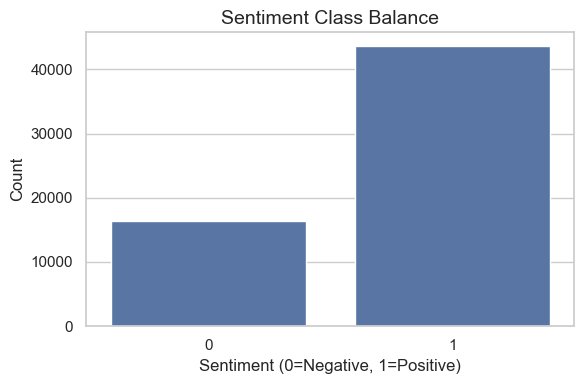

In [9]:
#Sentiment Plot
import seaborn as sns
sns.set(style="whitegrid", palette="deep")

plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Class Balance", fontsize=14)
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

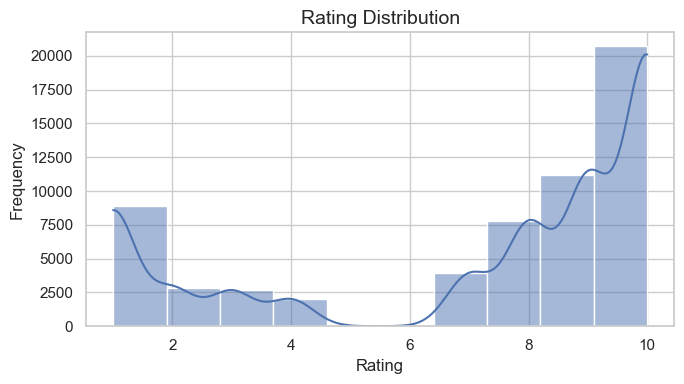

In [10]:
#Rating distribution
plt.figure(figsize=(7,4))
sns.histplot(df["rating"], bins=10, kde=True)
plt.title("Rating Distribution", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

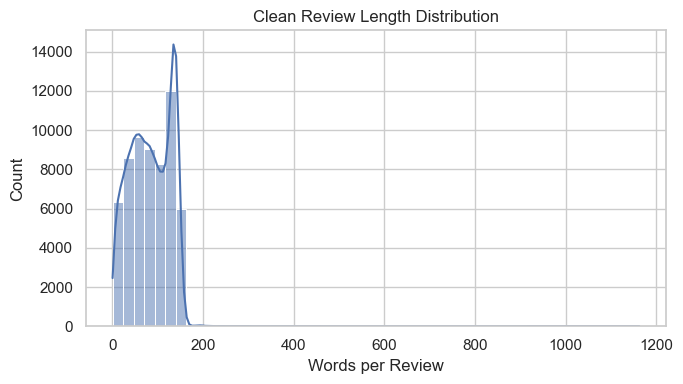

In [11]:
#Review length distribution
plt.figure(figsize=(7,4))
sns.histplot(df["review_len"], bins=50, kde=True)
plt.title("Clean Review Length Distribution")
plt.xlabel("Words per Review")
plt.tight_layout()
plt.show()

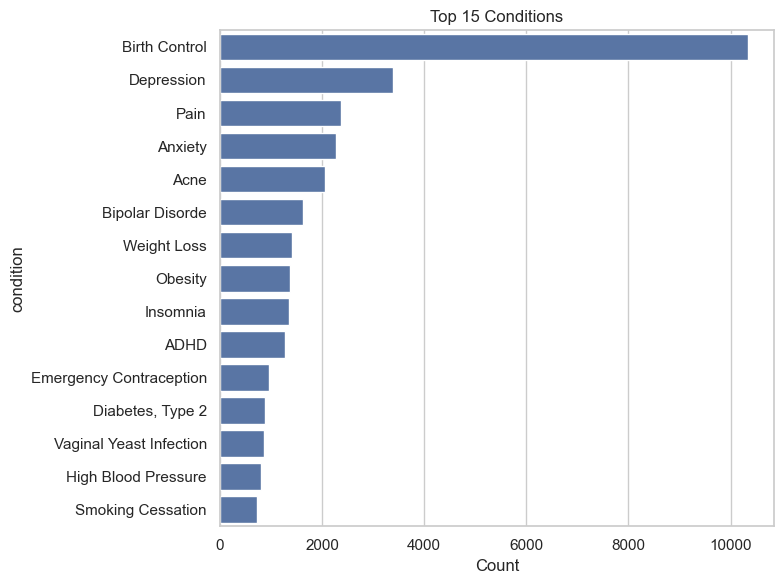

In [12]:
#Top 15 conditions
top_conditions = df["condition"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index
)
plt.title("Top 15 Conditions")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

In [13]:
df[["review", "clean_review", "rating", "sentiment", "condition"]].sample(5, random_state=42)

,review,clean_review,rating,sentiment,condition
12628,"""I took the dosage on Thursday night. It is Su...","""i took the dosage on thursday night. it is su...",4,0,Vaginal Yeast Infection
37730,"""Have been given Prednisone for severe back pa...","""have been given prednisone for severe back pa...",9,1,COPD
39991,"""Ortho Tri Cyclen Lo is probably the best pill...","""ortho tri cyclen lo is probably the best pill...",9,1,Birth Control
8525,"""I began the first prep at 6pm. I mixed it wi...","""i began the first prep at 6pm. i mixed it wit...",9,1,Bowel Preparation
8279,"""I had mine inserted on Nov 3rd, and here it i...","""i had mine inserted on nov 3rd, and here it i...",3,0,Abnormal Uterine Bleeding


### Overview
The dataset consists of 60,000 drug reviews with minimal missing values. The sentiment distribution is imbalanced (approximately 73% positive), which necessitates the use of F1-score rather than accuracy for evaluation. Ratings show strong polarization toward high scores (8–10), indicating that user satisfaction is skewed positive. Review length varies moderately, with most reviews between 20–200 words. The most frequent medical conditions include Birth Control, Depression, and Pain, suggesting strong thematic structure suitable for topic modeling.